In [1]:
#Construimos ahora un modelo de regresión logística. El objetivo de este modelo es saber la probabilidad de que el volumen del SP500
#un determinado día, sea mayor que el de los 30 días (de mercado) anteriores, ya que este es un indicador de volatilidad o interés del SP500
#y puede interesarnos a la hora de determinar si nos conviene o no vender nuestras participaciones.
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
#Descargamos los datos
df = yf.download('^GSPC', start='2014-01-01', end="2026-01-01")
#Los detalles de lo que escribo a continuación son iguales al caso de la regresión lineal.
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df=df.reset_index()
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2014-01-02,1831.979980,1845.859985,1827.739990,1845.859985,3080600000
1,2014-01-03,1831.369995,1838.239990,1829.130005,1833.209961,2774270000
2,2014-01-06,1826.770020,1837.160034,1823.729980,1832.310059,3294850000
3,2014-01-07,1837.880005,1840.099976,1828.709961,1828.709961,3511750000
4,2014-01-08,1837.489990,1840.020020,1831.400024,1837.900024,3652140000


In [3]:
df.info()
df.describe() 
#Observo que hay un día con volumen=0, y ya vimos que era un error en los datos, y lo rellenábamos con la mediana.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3018 non-null   datetime64[ns]
 1   Close   3018 non-null   float64       
 2   High    3018 non-null   float64       
 3   Low     3018 non-null   float64       
 4   Open    3018 non-null   float64       
 5   Volume  3018 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 141.6 KB


,Date,Close,High,Low,Open,Volume
count,3018,3018.000000,3018.000000,3018.000000,3018.000000,3.018000e+03
mean,2019-12-30 16:40:33.399602688,3474.133077,3491.834877,3453.828727,3473.566942,4.043852e+09
min,2014-01-02 00:00:00,1741.890015,1755.790039,1737.920044,1743.819946,0.000000e+00
25%,2016-12-29 06:00:00,2264.137512,2271.837524,2258.259949,2267.052551,3.406532e+09
50%,2019-12-30 12:00:00,3004.280029,3016.190063,2989.734985,3004.170044,3.835995e+09
75%,2022-12-27 18:00:00,4379.797363,4409.619995,4356.070068,4380.849976,4.466820e+09
max,2025-12-31 00:00:00,6932.049805,6945.770020,6921.600098,6936.020020,9.976520e+09
std,NaN,1353.254009,1359.846068,1345.706021,1353.046445,1.006061e+09


In [4]:
dias_con_vol0 = df[df['Volume'] == 0]
print(dias_con_vol0)
median_volume = df[df['Volume'] > 0]['Volume'].median()
df.loc[df['Volume'] == 0, 'Volume'] = median_volume

           Date        Close         High         Low         Open  Volume
2364 2023-05-24  4115.240234  4132.959961  4103.97998  4132.959961       0


In [ ]:
# Ahora debo definir la variable respuesta: ¿Es el volumen del día t+1 > media de los volúmenes de los días t,t-1,t-2,...t-29?
df['Vol_Media_30'] = df['Volume'].rolling(window=30).mean().shift(1)
#tengo que poner el shift(1) porque solo tengo datos hasta el día t.

df['target_futuro'] = ((df['Volume'] > df['Vol_Media_30']).astype(int)).shift(-1)    #Lo que pasará mañana


In [7]:
print(df)
#Vemos que los 30 primeros días, Vol_Media_30 es NaN (pues no tienen 30 días antes para comparar)
#Eliminamos estas filas pues dan problemas en el entrenamiento (consideramos respuesta 0 cuando no lo sabemos en realidad)


           Date        Close         High          Low         Open  \
0    2014-01-02  1831.979980  1845.859985  1827.739990  1845.859985   
1    2014-01-03  1831.369995  1838.239990  1829.130005  1833.209961   
2    2014-01-06  1826.770020  1837.160034  1823.729980  1832.310059   
3    2014-01-07  1837.880005  1840.099976  1828.709961  1828.709961   
4    2014-01-08  1837.489990  1840.020020  1831.400024  1837.900024   
...         ...          ...          ...          ...          ...   
3013 2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156   
3014 2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020   
3015 2025-12-29  6905.740234  6920.209961  6888.759766  6903.600098   
3016 2025-12-30  6896.240234  6913.250000  6893.470215  6900.439941   
3017 2025-12-31  6845.500000  6901.419922  6844.549805  6898.819824   

          Volume  Vol_Media_30  target_futuro  
0     3080600000           NaN            0.0  
1     2774270000           NaN            0.0  
2  

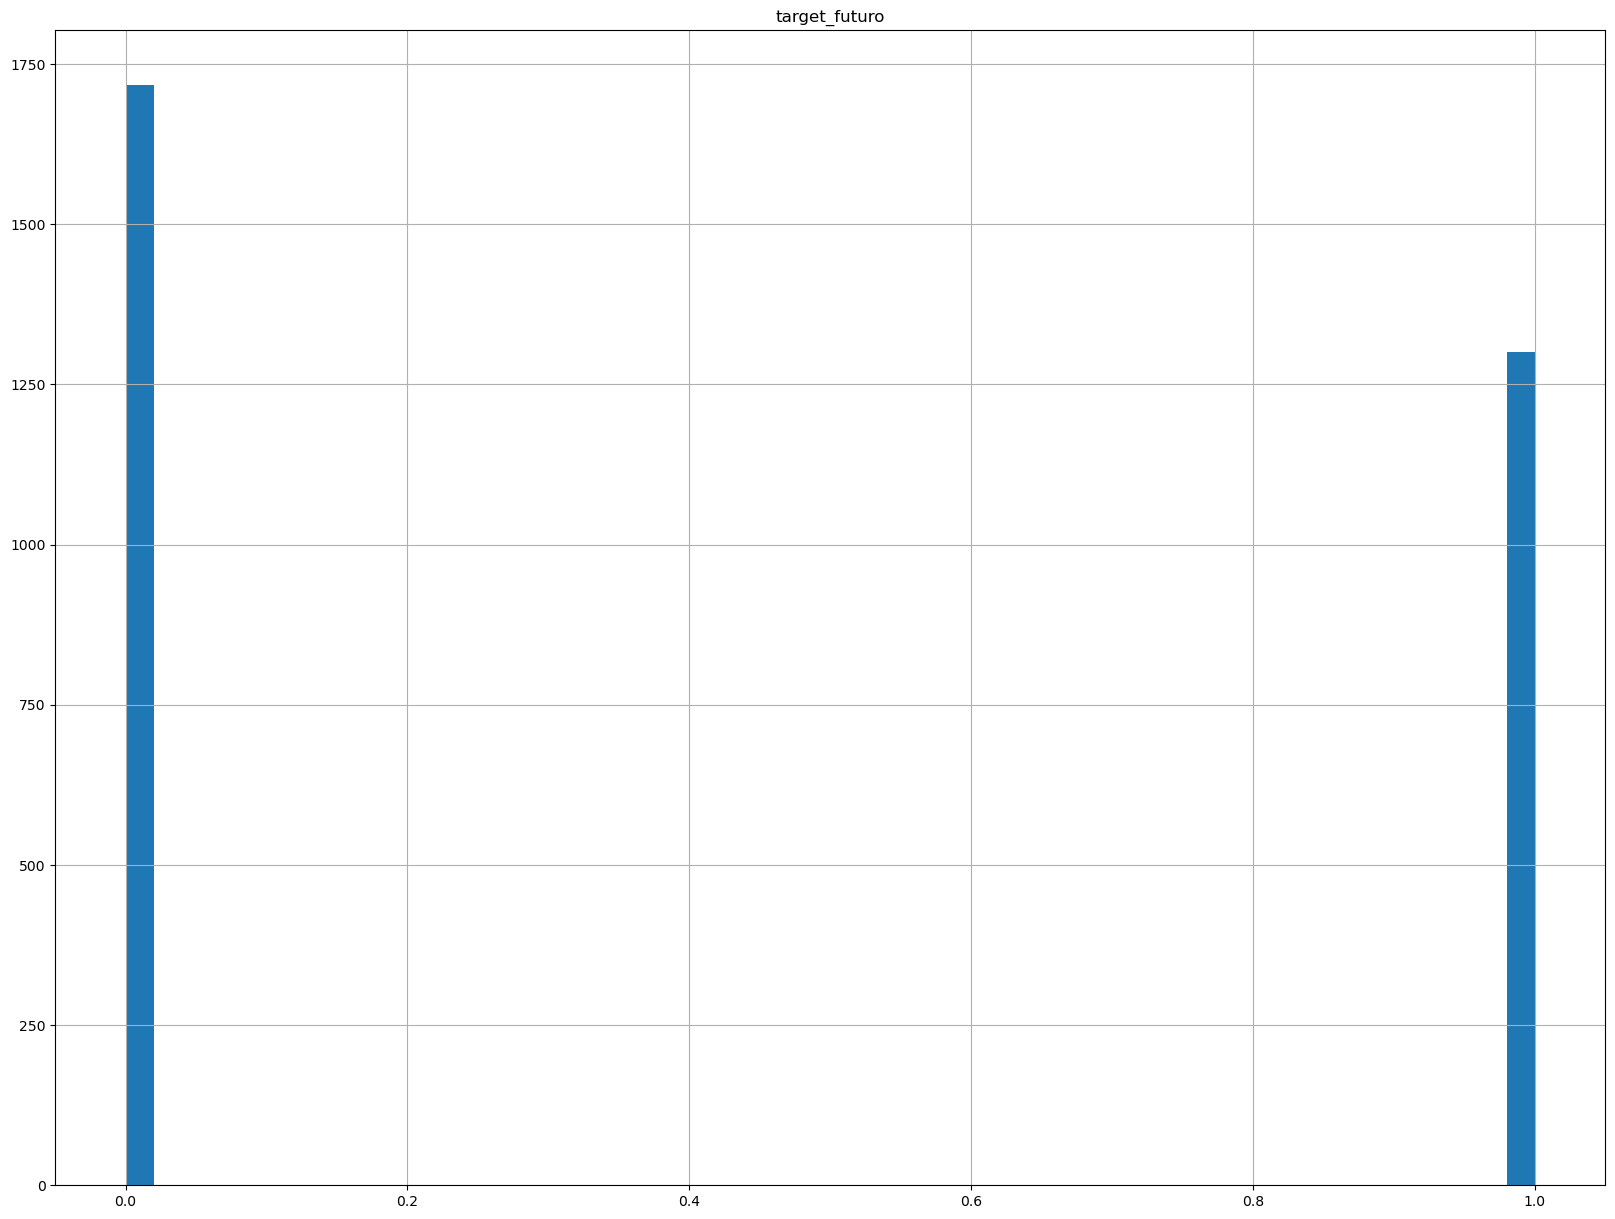

In [ ]:
#Hacemos histogramas: muestran el número de ejemplos (eje Y) que devuelven el valor en un determinado rango (eje X)
import matplotlib.pyplot as plt
%matplotlib inline
df[['target_futuro']].hist(bins=50, figsize=(20,15))
plt.show()
#Vemos que la diferencia entre 0 y 1 es de más o menos 300 casos.
#Ante un dataset de unos 3000 ejemplos, esto no es mucho desbalanceo. Es importante que los datos estén balanceados para que el modelo no se centre solo en la clase "mayoritaria".


In [9]:
#Definimos las características: 
X_cols = ['Vol_Media_30', 'Open', 'Close', 'High', 'Low', 'Volume']
y_col='target_futuro'

# Eliminamos las filas con NaNs (los primeros 30 días no tienen media ni lags completos)
df_model = df.dropna().copy()


In [10]:
len(df_model) 
#Se han eliminado 31 días, los 30 primeros y el último pues contenían NAs.
#Los primeros por el volumen de los 30 días anteriores y el último por la respuesta desconocida.

2987

In [11]:

print(df_model)

           Date        Close         High          Low         Open  \
30   2014-02-14  1838.630005  1841.650024  1825.589966  1828.459961   
31   2014-02-18  1840.760010  1842.869995  1835.010010  1839.030029   
32   2014-02-19  1828.750000  1847.500000  1826.989990  1838.900024   
33   2014-02-20  1839.780029  1842.790039  1824.579956  1829.239990   
34   2014-02-21  1836.250000  1846.130005  1835.599976  1841.069946   
...         ...          ...          ...          ...          ...   
3012 2025-12-23  6909.790039  6910.879883  6868.810059  6872.410156   
3013 2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156   
3014 2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020   
3015 2025-12-29  6905.740234  6920.209961  6888.759766  6903.600098   
3016 2025-12-30  6896.240234  6913.250000  6893.470215  6900.439941   

          Volume  Vol_Media_30  target_futuro  
30    3114750000  3.662649e+09            0.0  
31    3421110000  3.663788e+09            0.0  
32 

In [12]:
#Ahora hay que dividir los datos en Training/Test sets
tiempo=30
train_m=df_model.iloc[:-tiempo] #todo menos los últimos 30 días 
test_m =df_model.iloc[-tiempo:] #solo los últimos 30 días (conozco las respuestas pero los voy a usar como test y quiero ver la precisión de las predicciones)
X_train = train_m[X_cols]
y_train = train_m[y_col]
X_test = test_m[X_cols]
y_test = test_m[y_col]
#X_test e y_test no se pueden usar porque son datos que aparentemente no conocemos, solo conocemos los datos de entrenamiento.


In [13]:
#De nuevo, es importante escalar los atributos:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Ahora entreno el modelo:
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
#Ahora que tenemos el modelo entrenado, vamos a ver si las predicciones que hace son buenas o no.

probabilidades = model.predict_proba(X_test_scaled)[:,1]
#Observamos que es una matriz con muchos ceros y unos pocos unos
#Probabilidades de que sea 1:
predicciones=model.predict(X_test_scaled)
#predict_proba devuelve [prob_de_0, prob_de_1] --> nos quedamos con la probabilidad de 1

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predicciones)
#Obtenemos un 70% de precisión. Sin embargo observamos que casi todas las predicciones que hace son 0.
#Esto sucede porque en el test set (los últimos 20 días), es muy probable que el volumen real haya sido bajo en el 75% de los casos.
#Por lo que el modelo no ha aprendido, sino que ha tenido suerte con la clase mayoritaria.


0.7

In [17]:
predicciones

array([0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [18]:
probabilidades
#Vemos que todas están alrededor del 0.45, con lo cual el modelo casi nunca predice 1.
#Esto indica una ausencia de poder predictivo lineal para el horizonte temporal de 20 días.

array([0.29370287, 0.28027596, 0.24443222, 0.45939522, 0.52797108,
       0.57102877, 0.23936882, 0.14099671, 0.01240159, 0.1915252 ,
       0.20657274, 0.24134136, 0.28715247, 0.31738173, 0.2752912 ,
       0.21187029, 0.5278347 , 0.36287372, 0.35811514, 0.38918433,
       0.4042429 , 0.47843142, 0.46809153, 0.99021039, 0.24997952,
       0.13014523, 0.01028999, 0.0359866 , 0.13789171, 0.11523219])

In [19]:
comparativa = pd.DataFrame({
    'Fecha_Analizada': test_m['Date'].values,
    # El target ya representa lo que pasó 30 días después de 'Fecha_Analizada'
    'Realidad_T': y_test.values, 
    'Prediccion_T': predicciones,
    'Probabilidad': (probabilidades * 100).round(2)
})
comparativa

,Fecha_Analizada,Realidad_T,Prediccion_T,Probabilidad
0,2025-11-17,0.0,0.0,29.37
1,2025-11-18,0.0,0.0,28.03
2,2025-11-19,1.0,0.0,24.44
3,2025-11-20,1.0,0.0,45.94
4,2025-11-21,1.0,1.0,52.80
5,2025-11-24,0.0,1.0,57.10
6,2025-11-25,0.0,0.0,23.94
7,2025-11-26,0.0,0.0,14.10
8,2025-11-28,0.0,0.0,1.24
9,2025-12-01,0.0,0.0,19.15


In [ ]:
from sklearn.metrics import log_loss, roc_auc_score

print(f"Log-Loss: {log_loss(y_test, probabilidades):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, probabilidades):.4f}")
#El AUC (Área Bajo la Curva) mide qué tan bueno es el modelo para separar las clases. 
#Como AUC=0.75 aprox. El modelo acierta un 60% de las veces al asignar una probabilidad más alta al día que realmente tuvo volumen alto.
#Como log-loss es 0.61 aproximadamenre, hay bastante pérdida--> como hemos visto, el modelo no es muy bueno.


Log-Loss: 0.6004
AUC-ROC: 0.7516


In [ ]:
#En conclusión, los resultados nos muestran que el modelo:
#-Tiene baja capacidad predictiva.
#-No puede capturar bien patrones temporales.
#Ya vimos que realmente el modelo no estaba muy desbalanceado, así que el problema aquí es que entre las variables predictoras y la respuesta, no existe una relación lineal. 